# 4 Model Evaluation and Comparison

**Project:** Predictive Modeling of US Used Vehicle Prices
**Course:** ENGR422 Applied Machine Learning
**Authors:** Eren Acar Başaran (83179), Ahmet Aybars Pektaş (91687)

This is the final notebook. We compare all trained models on the held out test set. The test set is from notebook 02 and is used only here.

**Deliverables**
- D4.1 Model Performance Comparison Metrics in 4.2
- D4.2 Final Project Presentation built from the plots in 4.3 to 4.5

**Code organization note.** We import shared helpers from src/utils.py for loading data and models. All four model notebooks use the same loaders. The splits and preprocessor instances are byte identical across notebooks. This stops apples to oranges bugs.


## 4.1 Imports and load trained models

Load the held out test set with load_test from utils. Load the trained model pipelines from 03a 03b 03c and 03d.

We also load extra XGBoost variants if they exist on disk. The reduced features version and the early stopping version from the ablation in 3C.5.1.


In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path so joblib can find the custom transformers.
sys.path.insert(0, "../src")
import preprocessing  # noqa: F401
from utils import (
    load_test, load_model,
    regression_metrics, metrics_table,
    plot_pred_vs_actual, plot_residuals,
    MODELS_DIR,
)

X_test, y_test = load_test()
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Load the four models from 03a 03b 03c 03d.
models = {
    "Linear Regression (Ridge)": load_model("linear_regression"),
    "Random Forest":             load_model("random_forest"),
    "XGBoost":                   load_model("xgboost"),
}

# LightGBM from 03d if saved.
lgbm_path = MODELS_DIR / "lightgbm.pkl"
if lgbm_path.exists():
    models["LightGBM"] = joblib.load(lgbm_path)

# Reduced features XGBoost.
reduced_path = MODELS_DIR / "xgboost_reduced.pkl"
if reduced_path.exists():
    models["XGBoost (reduced features)"] = joblib.load(reduced_path)

# Early stopping XGBoost from 3C.5.1.
es_path = MODELS_DIR / "xgboost_early_stop.pkl"
if es_path.exists():
    models["XGBoost (early stopping)"] = joblib.load(es_path)

print(f"loaded {len(models)} models: {list(models.keys())}")


X_test: (76286, 12), y_test: (76286,)


loaded 6 models: ['Linear Regression (Ridge)', 'Random Forest', 'XGBoost', 'LightGBM', 'XGBoost (reduced features)', 'XGBoost (early stopping)']


## 4.2 Performance comparison table D4.1

The main result of WP4. We predict on the test set with each model. We compute four metrics MAE RMSE R squared and MAPE. We show the table and two bar charts.

Lower is better for MAE RMSE and MAPE. Higher is better for R squared. The cell below also prints the per metric winner.


Test set metrics:
                                MAE     RMSE      R2   MAPE
Linear Regression (Ridge)   5378.11  8512.62  0.6509  77.10
Random Forest               2154.14  4825.40  0.8878  36.77
XGBoost                     2024.06  4514.81  0.9018  32.55
LightGBM                    2177.79  4531.57  0.9011  35.63
XGBoost (reduced features)  2251.23  4944.18  0.8822  39.29
XGBoost (early stopping)    2090.66  4610.49  0.8976  33.56

Per metric winners:
  MAE  : XGBoost  (2024.060)
  RMSE : XGBoost  (4514.807)
  R2   : XGBoost  (0.902)
  MAPE : XGBoost  (32.545)


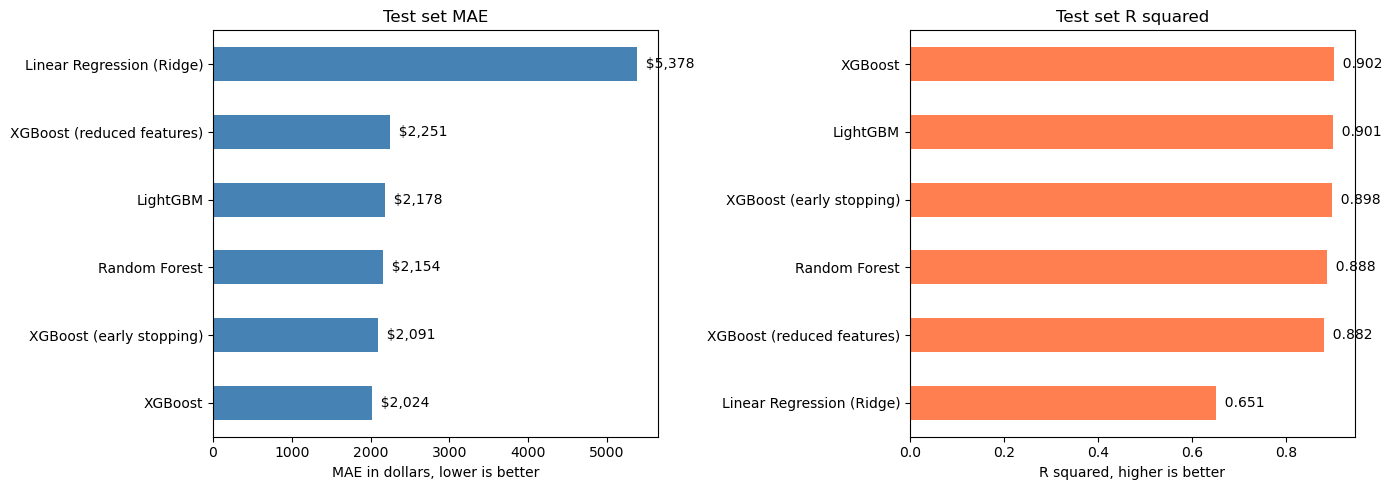

In [2]:
# Predict on the held out test set.
predictions = {name: m.predict(X_test) for name, m in models.items()}

# Comparison table. D4.1.
metrics_df = metrics_table(predictions, y_test)

# Rounded for display.
display_df = metrics_df.round({"MAE": 2, "RMSE": 2, "R2": 4, "MAPE": 2})
print("Test set metrics:")
print(display_df.to_string())

# Winners per metric.
print("\nPer metric winners:")
for col, best in [("MAE", "min"), ("RMSE", "min"), ("R2", "max"), ("MAPE", "min")]:
    idx = metrics_df[col].idxmin() if best == "min" else metrics_df[col].idxmax()
    print(f"  {col:5}: {idx}  ({metrics_df.loc[idx, col]:.3f})")

# Bar charts. MAE left. R squared right.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_df["MAE"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_xlabel("MAE in dollars, lower is better")
axes[0].set_title("Test set MAE")
for i, v in enumerate(metrics_df["MAE"].sort_values()):
    axes[0].text(v, i, f"  ${v:,.0f}", va="center")

metrics_df["R2"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_xlabel("R squared, higher is better")
axes[1].set_title("Test set R squared")
for i, v in enumerate(metrics_df["R2"].sort_values()):
    axes[1].text(v, i, f"  {v:.3f}", va="center")

plt.tight_layout()
plt.show()


### 4.2.1 Feature selection verdict

Does reducing XGBoost to its top half features help or hurt on the test set. The metrics table above already shows both rows. This cell makes the verdict explicit. The verdict text auto updates if the run changes.


In [3]:
# Full vs reduced XGBoost summary.
if "XGBoost (reduced features)" in metrics_df.index:
    full_mae    = metrics_df.loc["XGBoost",                    "MAE"]
    full_r2     = metrics_df.loc["XGBoost",                    "R2"]
    reduced_mae = metrics_df.loc["XGBoost (reduced features)", "MAE"]
    reduced_r2  = metrics_df.loc["XGBoost (reduced features)", "R2"]
    delta_mae   = reduced_mae - full_mae

    print(f"Full XGBoost:    test MAE = ${full_mae:,.2f}, R squared = {full_r2:.4f}")
    print(f"Reduced XGBoost: test MAE = ${reduced_mae:,.2f}, R squared = {reduced_r2:.4f}")
    print(f"Delta reduced minus full: ${delta_mae:+,.2f} MAE")

    tolerance = 0.01 * full_mae
    if delta_mae > tolerance:
        verdict = f"feature selection HURT the model on test, lost ${delta_mae:,.0f}, ~{100*delta_mae/full_mae:.1f}%"
    elif delta_mae < -tolerance:
        verdict = f"feature selection HELPED on test, saved ${-delta_mae:,.0f}, ~{100*-delta_mae/full_mae:.1f}%"
    else:
        verdict = "feature selection was approximately NEUTRAL on test, within ~1% of full model"
    print(f"\nVerdict: {verdict}.")
else:
    print("xgboost_reduced.pkl not loaded, comparison skipped.")


Full XGBoost:    test MAE = $2,024.06, R squared = 0.9018
Reduced XGBoost: test MAE = $2,251.23, R squared = 0.8822
Delta reduced minus full: $+227.17 MAE

Verdict: feature selection HURT the model on test, lost $227, ~11.2%.


### 4.2.2 Tuning method ablation

Two XGBoost models with the same other hyperparameters but different ways to pick the tree count.

- Random search picked a fixed n_estimators from the search range.
- Early stopping in 3C.5.1 watched a small validation slice and stopped adding trees when MAE stopped improving.

The cell below loads both pkls and prints the verdict on the test set. If xgboost_early_stop.pkl is missing the cell skips.


Random search:  test MAE = $2,024.06, R squared = 0.9018
Early stopping: test MAE = $2,090.66, R squared = 0.8976
Delta early stopping minus random search: $+66.60 MAE

Verdict: Early stopping HURT, lost $67 (3.3%).


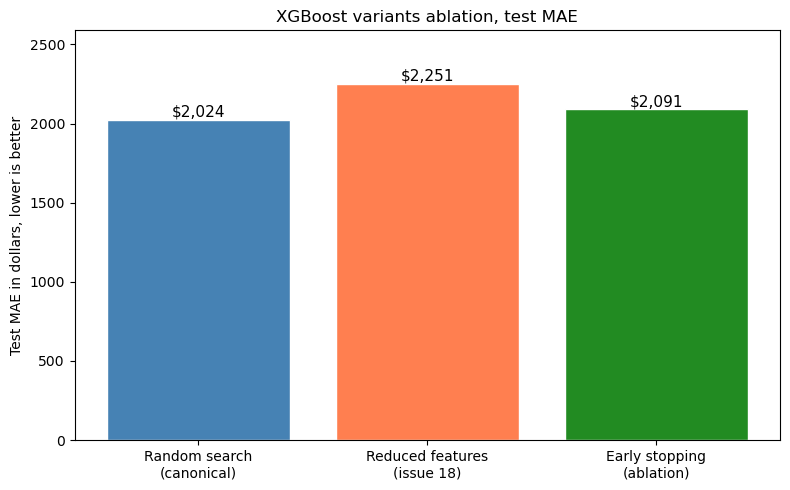

In [4]:
# Random search vs early stopping.
if "XGBoost (early stopping)" in metrics_df.index and "XGBoost" in metrics_df.index:
    rs_mae = metrics_df.loc["XGBoost", "MAE"]
    es_mae = metrics_df.loc["XGBoost (early stopping)", "MAE"]
    rs_r2  = metrics_df.loc["XGBoost", "R2"]
    es_r2  = metrics_df.loc["XGBoost (early stopping)", "R2"]
    delta  = es_mae - rs_mae

    print(f"Random search:  test MAE = ${rs_mae:,.2f}, R squared = {rs_r2:.4f}")
    print(f"Early stopping: test MAE = ${es_mae:,.2f}, R squared = {es_r2:.4f}")
    print(f"Delta early stopping minus random search: ${delta:+,.2f} MAE")

    tol = 0.01 * rs_mae
    if delta < -tol:
        verdict = f"Early stopping HELPED, saved ${-delta:,.0f} ({100*-delta/rs_mae:.1f}%)"
    elif delta > tol:
        verdict = f"Early stopping HURT, lost ${delta:,.0f} ({100*delta/rs_mae:.1f}%)"
    else:
        verdict = "Approximately NEUTRAL, within ~1% of random search"
    print(f"\nVerdict: {verdict}.")

    # Bar chart for the variants ablation.
    variants = ["XGBoost", "XGBoost (reduced features)", "XGBoost (early stopping)"]
    available = [v for v in variants if v in metrics_df.index]
    if len(available) >= 2:
        labels_short = {
            "XGBoost":                     "Random search\n(canonical)",
            "XGBoost (reduced features)":  "Reduced features\n(ablation)",
            "XGBoost (early stopping)":    "Early stopping\n(ablation)",
        }
        maes = [metrics_df.loc[v, "MAE"] for v in available]
        labels = [labels_short[v] for v in available]
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(labels, maes, color=["steelblue", "coral", "forestgreen"][:len(available)],
                      edgecolor="white")
        ax.set_ylabel("Test MAE in dollars, lower is better")
        ax.set_title("XGBoost variants ablation, test MAE")
        for bar, v in zip(bars, maes):
            ax.text(bar.get_x() + bar.get_width()/2, v, f"${v:,.0f}",
                    ha="center", va="bottom", fontsize=11)
        ax.set_ylim(0, max(maes) * 1.15)
        plt.tight_layout()
        plt.show()
else:
    print("xgboost_early_stop.pkl not loaded, ablation skipped.")


## 4.3 Visual comparison

Two plots per model.

The scatter shows predicted price against actual price. The dashed line is perfect prediction. Closer to the line is better.

The residual histogram shows the error distribution. Centered narrow and symmetric is good. Skewed is systematic bias.

We plot one row per model so the differences are easy to see. We also add a compact overlay at the end that puts all models residual distributions on one chart. The overlay is the slide friendly version.


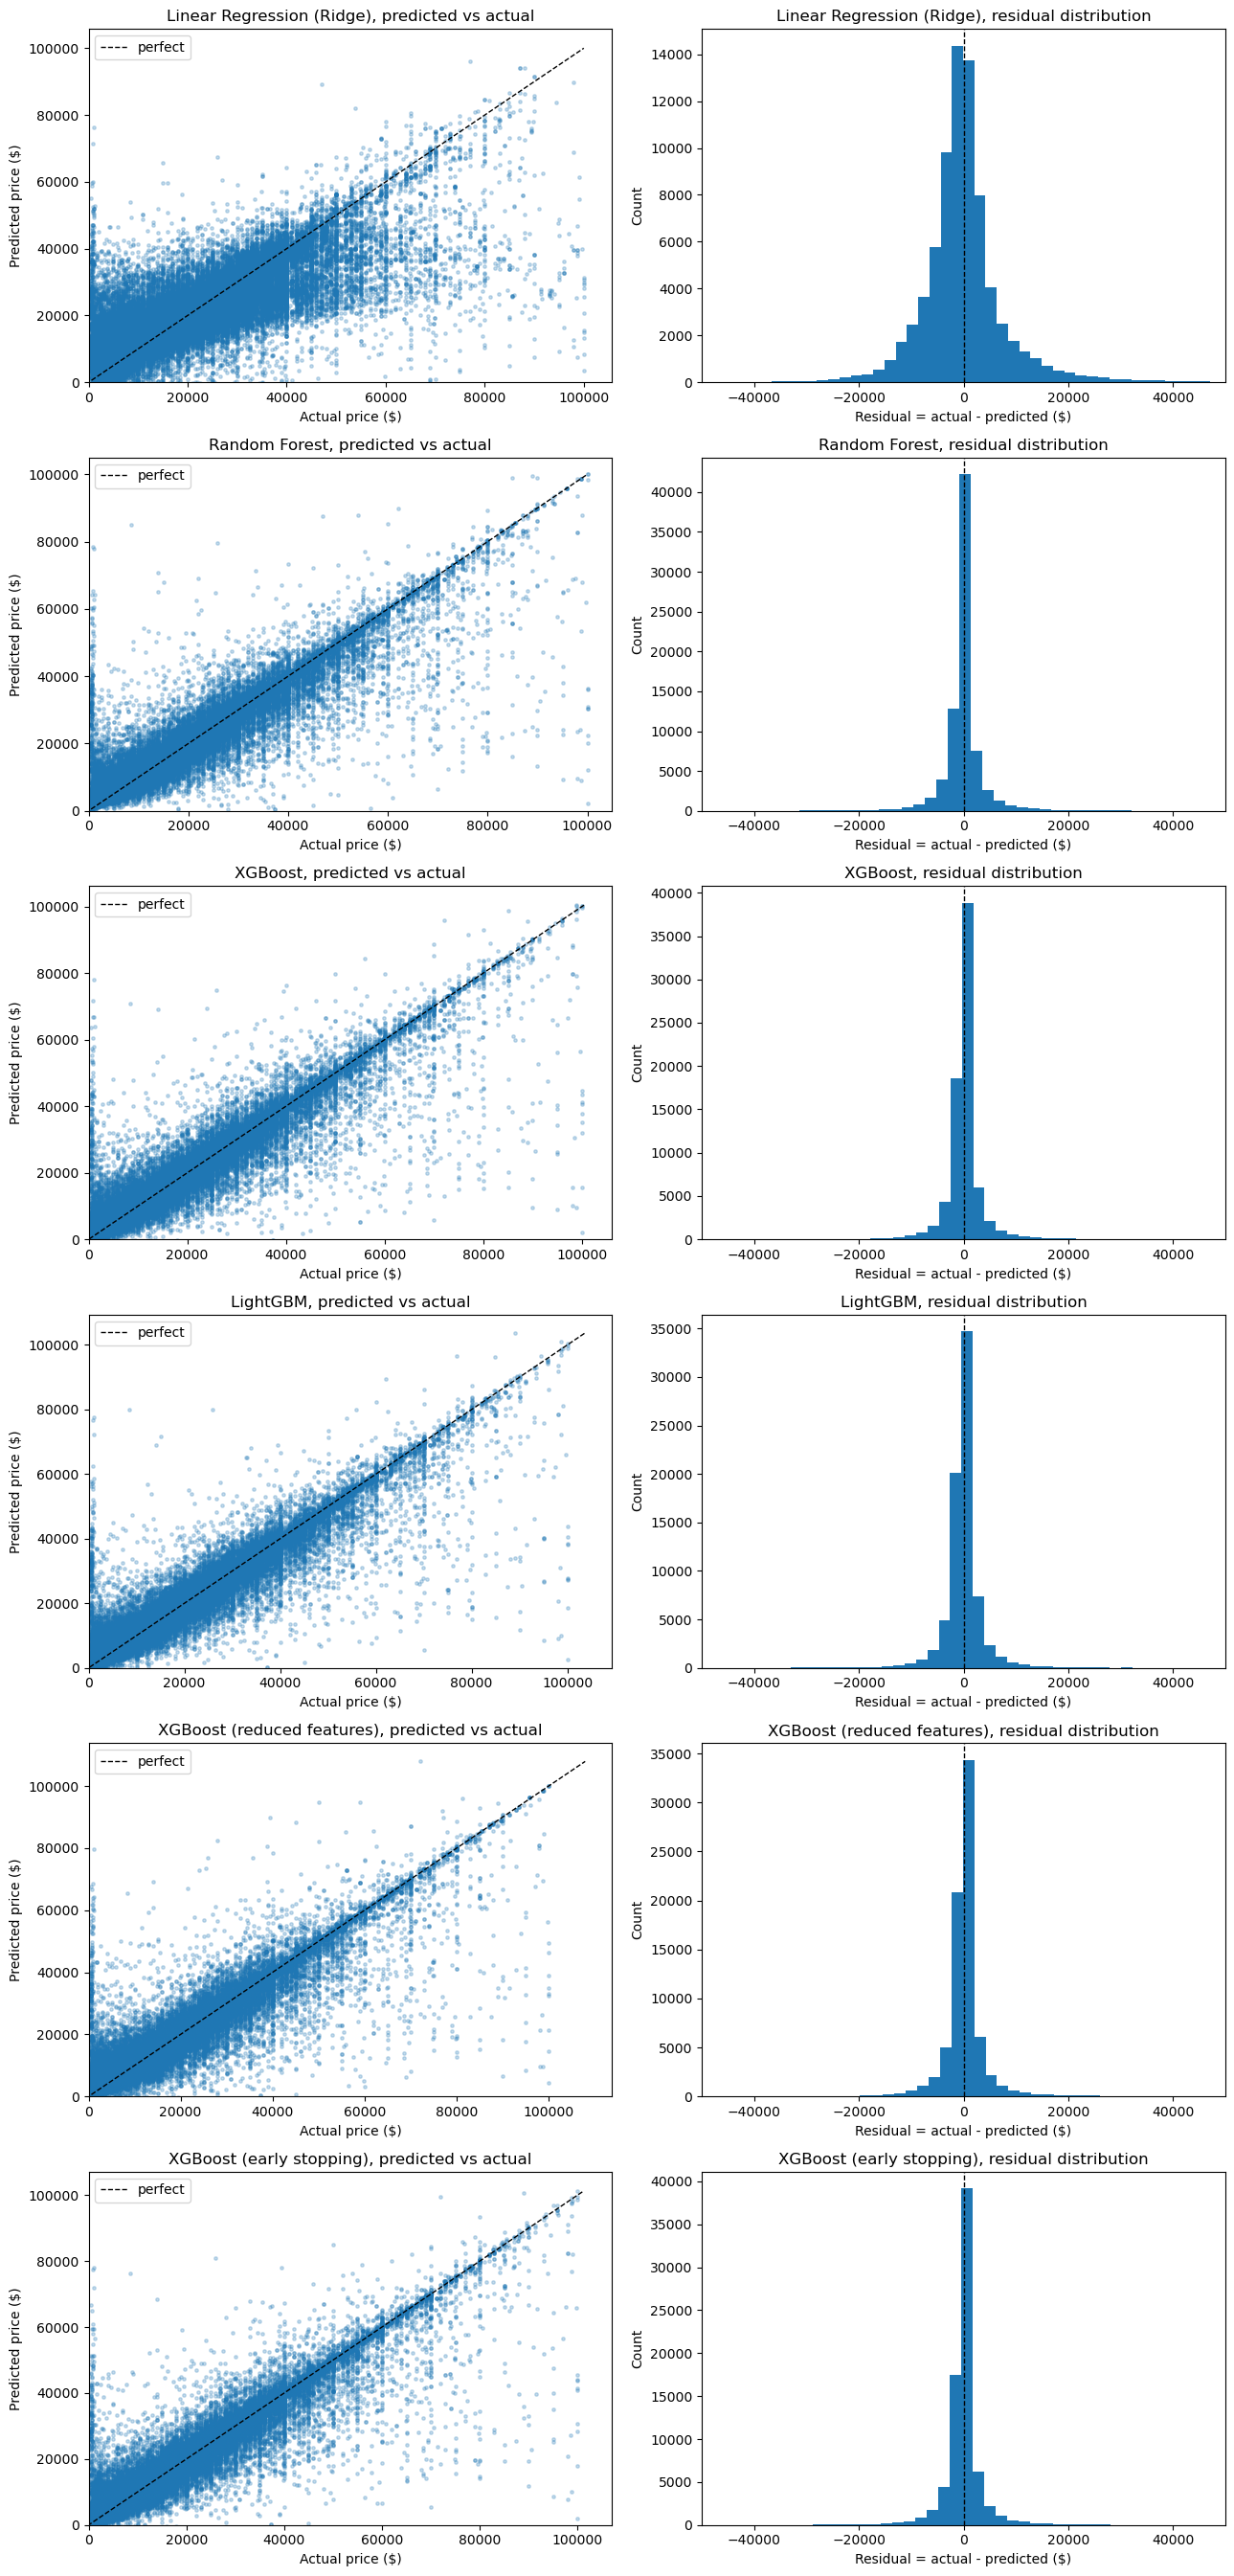

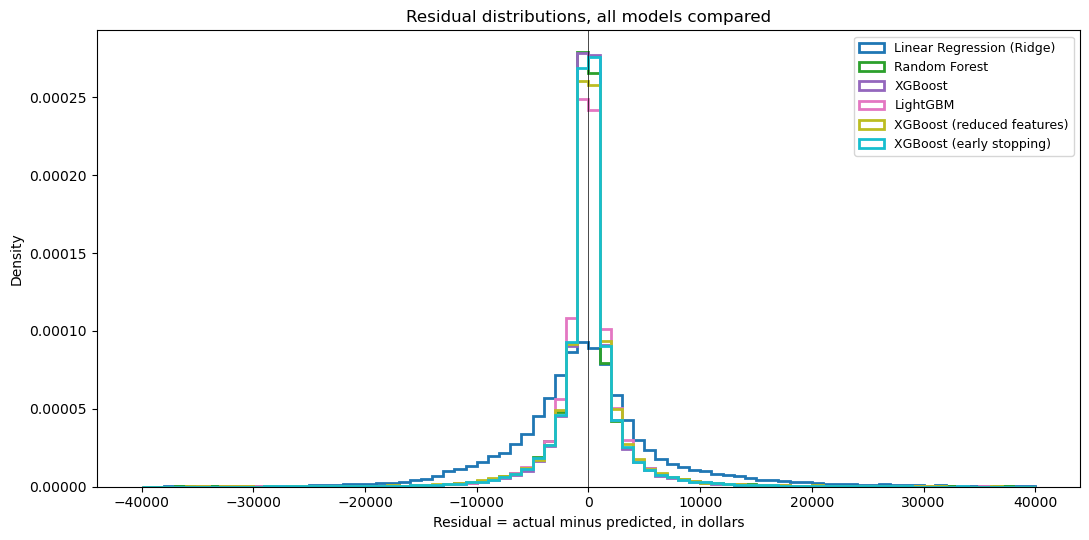

In [5]:
n = len(predictions)
fig, axes = plt.subplots(n, 2, figsize=(13, 4.5 * n))
if n == 1:
    axes = axes.reshape(1, 2)
for i, (name, y_pred) in enumerate(predictions.items()):
    plot_pred_vs_actual(y_test, y_pred, ax=axes[i, 0],
                        title=f"{name}, predicted vs actual")
    plot_residuals(y_test, y_pred, ax=axes[i, 1],
                   title=f"{name}, residual distribution")
    # Prices are non negative. Pin axes to 0.
    axes[i, 0].set_xlim(left=0)
    axes[i, 0].set_ylim(bottom=0)
    # Limit residual view to +/- 50k.
    axes[i, 1].set_xlim(-50_000, 50_000)
plt.tight_layout()
plt.show()

# Slide friendly overlay. All models on one axis.
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(predictions)))
for (name, y_pred), color in zip(predictions.items(), colors):
    residuals = y_test.values - y_pred
    ax.hist(residuals, bins=80, range=(-40_000, 40_000),
            histtype="step", linewidth=2, label=name, color=color, density=True)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Residual = actual minus predicted, in dollars")
ax.set_ylabel("Density")
ax.set_title("Residual distributions, all models compared")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()


## 4.4 Feature importance comparison

Random Forest XGBoost and LightGBM all expose tree based feature importance. We plot the top 15 features for each so the reader can see if the three tree models agree on the drivers of price.

Linear regression coefficients are not shown here. They live in scaled feature space and are not directly comparable to tree importances. See section 3A.5 in the linear notebook for those.


Top 15 features by XGBoost importance, each column normalized to its own max:
                           Random Forest  XGBoost  LightGBM
feature                                                    
target__model                     1.0000   1.0000    1.0000
year__year                        0.2629   0.4224    0.7606
ohe__transmission_other           0.0137   0.3605    0.0499
ohe__fuel_gas                     0.0221   0.3458    0.0759
ohe__fuel_other                   0.0058   0.2889    0.0254
ohe__drive_fwd                    0.0128   0.2575    0.0671
ohe__title_status_salvage         0.0011   0.2059    0.0080
ohe__title_status_rebuilt         0.0019   0.1963    0.0147
ohe__title_status_missing         0.0002   0.1877    0.0031
ohe__fuel_hybrid                  0.0005   0.1407    0.0044
ohe__type_truck                   0.0060   0.1320    0.0645
ohe__type_convertible             0.0014   0.1281    0.0164
ohe__drive_rwd                    0.0070   0.1209    0.0857
ohe__type_other       

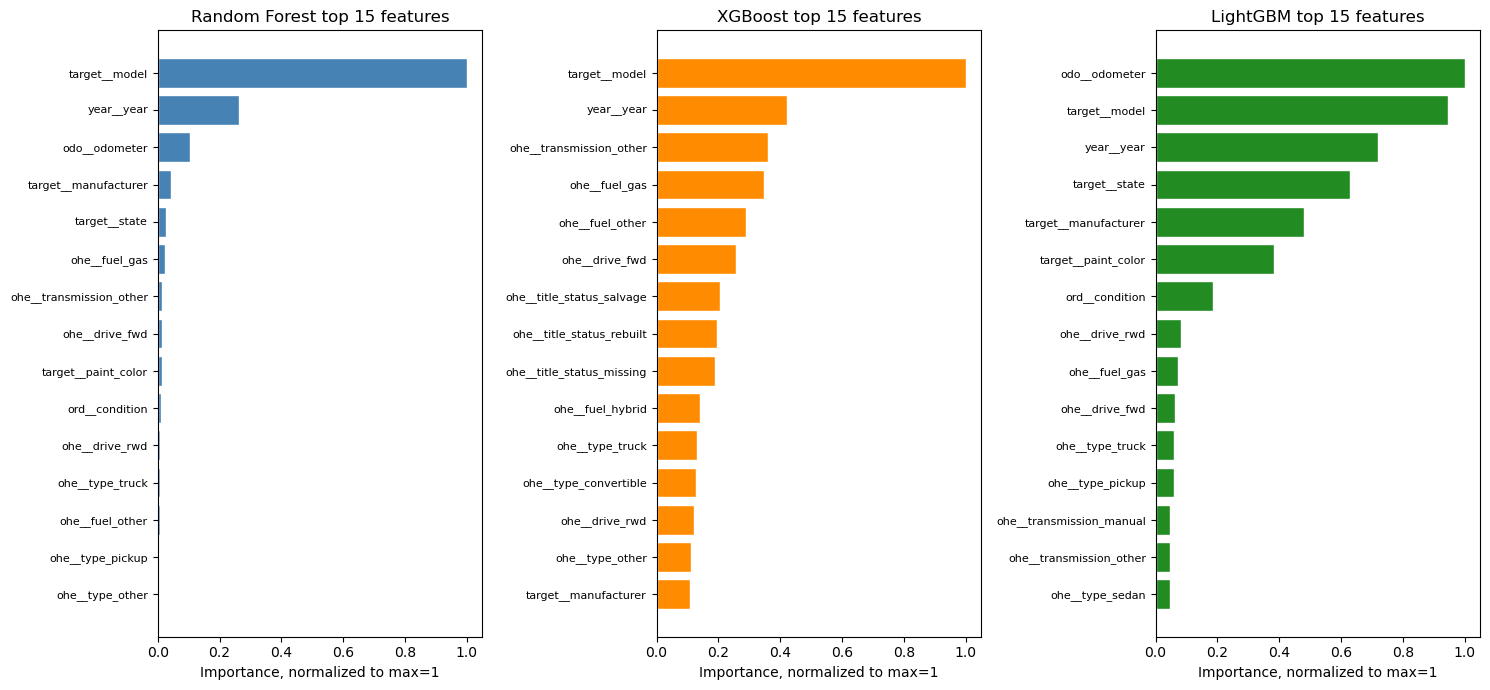

In [6]:
def find_estimator(pipeline):
    """Return the step in pipeline that has feature_importances_ or coef_."""
    for name, step in pipeline.named_steps.items():
        if hasattr(step, "feature_importances_") or hasattr(step, "coef_"):
            return name, step
    raise ValueError("no estimator like step found in pipeline")

def feat_names_from_pipeline(pipeline):
    """Get feature names from the encode ColumnTransformer."""
    encode = pipeline.named_steps["prep"].named_steps["encode"]
    parts = []
    for tname, trans, cols in encode.transformers_:
        if tname == "ohe":
            ohe_names = encode.named_transformers_["ohe"].get_feature_names_out(cols)
            parts.extend(f"ohe__{n}" for n in ohe_names)
        else:
            parts.extend(f"{tname}__{c}" for c in cols)
    return np.asarray(parts)

# RF LightGBM and XGB share the tree preprocessor.
feat_names = feat_names_from_pipeline(models["XGBoost"])

# Importance arrays per tree model.
tree_models = {}
for name in ["Random Forest", "XGBoost", "LightGBM"]:
    if name in models:
        _, est = find_estimator(models[name])
        tree_models[name] = est.feature_importances_

# Top 15 by XGBoost importance.
xgb_imp = tree_models["XGBoost"]
top_idx = np.argsort(xgb_imp)[::-1][:15]

# Each model uses a different importance scale.
# Three subplots side by side. Each ranked by its own model.

# Combined table. Each column normalized to max=1.
top_idx_xgb = np.argsort(tree_models["XGBoost"])[::-1][:15]
imp_df = pd.DataFrame(
    {name: imp[top_idx_xgb] for name, imp in tree_models.items()},
    index=feat_names[top_idx_xgb],
)
imp_df.index.name = "feature"
imp_df_norm = imp_df.apply(lambda col: col / col.max())

print("Top 15 features by XGBoost importance, each column normalized to its own max:")
print(imp_df_norm.round(4))

# Three subplots. Each model has its own top 15.
fig, axes = plt.subplots(1, len(tree_models), figsize=(15, 7), sharey=False)
colors = ["steelblue", "darkorange", "forestgreen"]
for ax, (name, imp), color in zip(axes, tree_models.items(), colors):
    top_idx = np.argsort(imp)[::-1][:15]
    names = feat_names[top_idx]
    vals = imp[top_idx] / imp[top_idx].max()
    ax.barh(range(len(names)), vals[::-1], color=color, edgecolor="white")
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names[::-1], fontsize=8)
    ax.set_xlabel("Importance, normalized to max=1")
    ax.set_title(f"{name} top 15 features")
    ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()


## 4.5 Error analysis

Where does the best model make its biggest mistakes. Three slices.

- By price band. Does the model fail more on cheap cars or on expensive cars.
- By manufacturer. Does it know Toyota better than Tesla.
- Top 10 worst predictions. Concrete listings for the writeup.

We also add a per model price band chart at the end. This shows which model wins which price segment, not just the overall best.


Best model on test set: XGBoost  (MAE = $2,024.06)

Mean absolute error by price band:
             mean  median  count
actual                          
<$5K       2289.0   892.0  10748
$5K-15K    1579.0   902.0  26279
$15K-30K   1830.0   785.0  23588
$30K-50K   2152.0   526.0  13255
$50K-100K  6874.0  1442.0   2416

Mean absolute error by manufacturer, top 12 by listing count:
                 mean  count
manufacturer                
hyundai        1178.0   1828
honda          1322.0   3758
nissan         1442.0   3423
toyota         1680.0   6269
bmw            1879.0   2648
jeep           2082.0   3364
dodge          2223.0   2314
chevrolet      2296.0   9921
ford           2329.0  12797
gmc            2425.0   2997
ram            2499.0   3138
mercedes-benz  2514.0   2018

Top 10 worst predicted listings:
         year   manufacturer             model  odometer  actual     predicted     abs_error
27659  1997.0      chevrolet  express 2500 4x4  195469.0  100000   2020.601807  97979.

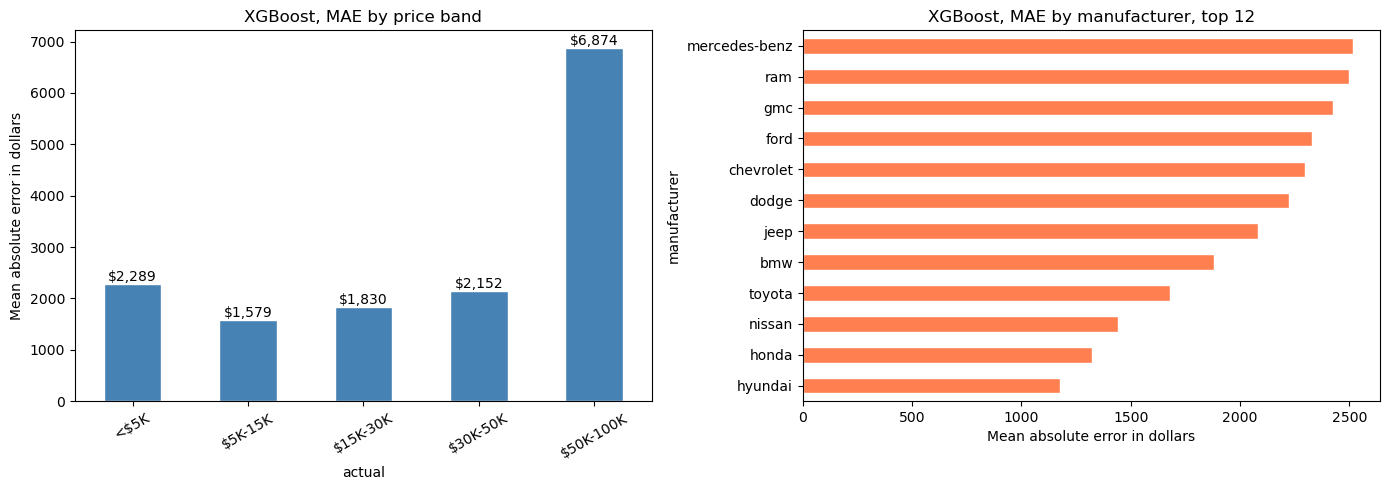


MAE by price band, per model:
           Linear Regression (Ridge)  Random Forest  XGBoost  LightGBM  XGBoost (reduced features)  XGBoost (early stopping)
<$5K                          6164.0         2601.0   2288.0    2449.0                      2784.0                    2370.0
$5K-15K                       4172.0         1635.0   1573.0    1647.0                      1785.0                    1619.0
$15K-30K                      4157.0         1875.0   1835.0    1988.0                      2011.0                    1894.0
$30K-50K                      6512.0         2223.0   2154.0    2381.0                      2276.0                    2233.0
$50K-100K                    20577.0         8037.0   6744.0    7336.0                      7054.0                    6989.0


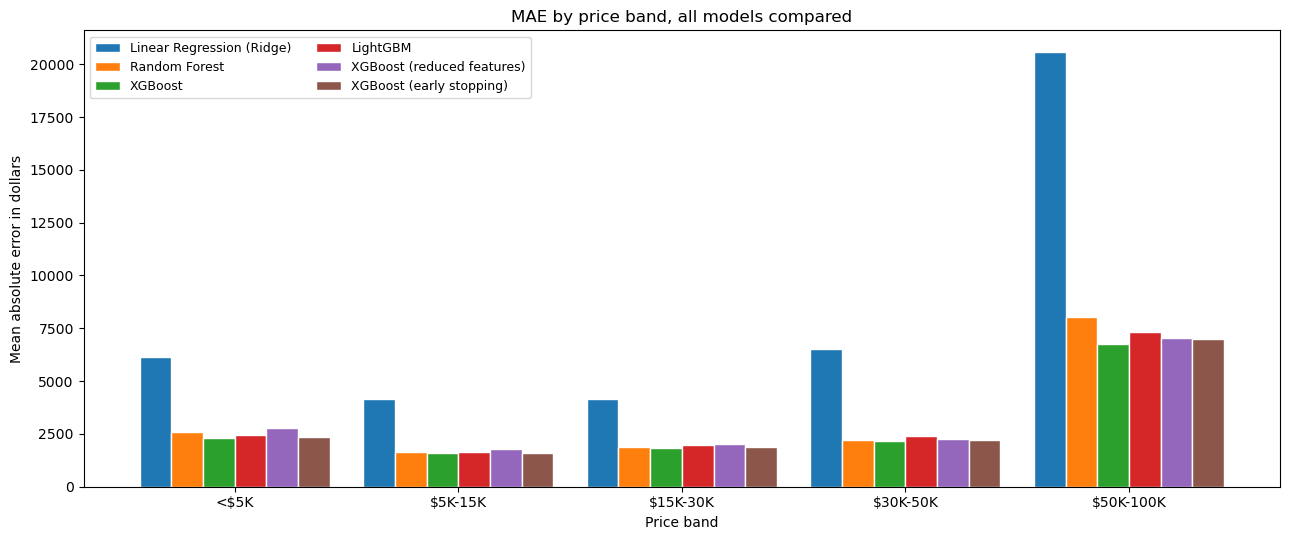

In [7]:
# Lowest MAE model on the test set.
best_name = metrics_df["MAE"].idxmin()
best_pred = predictions[best_name]
print(f"Best model on test set: {best_name}  (MAE = ${metrics_df.loc[best_name, 'MAE']:,.2f})")

abs_err = np.abs(y_test.values - best_pred)
test_view = X_test.copy()
test_view["actual"]    = y_test.values
test_view["predicted"] = best_pred
test_view["abs_error"] = abs_err

# Error by price band.
bands = pd.cut(test_view["actual"],
               bins=[0, 5000, 15000, 30000, 50000, 100000],
               labels=["<$5K", "$5K-15K", "$15K-30K", "$30K-50K", "$50K-100K"])
err_by_band = test_view.groupby(bands, observed=True)["abs_error"].agg(
    ["mean", "median", "count"]
).round(0)
print("\nMean absolute error by price band:")
print(err_by_band)

# Error by manufacturer. Top 12 by listing count.
top_mfrs = test_view["manufacturer"].value_counts().head(12).index
err_by_mfr = (
    test_view[test_view["manufacturer"].isin(top_mfrs)]
    .groupby("manufacturer", observed=True)["abs_error"]
    .agg(["mean", "count"])
    .round(0)
    .sort_values("mean")
)
print("\nMean absolute error by manufacturer, top 12 by listing count:")
print(err_by_mfr)

# Top 10 worst predictions.
worst = test_view.nlargest(10, "abs_error")[
    ["year", "manufacturer", "model", "odometer", "actual", "predicted", "abs_error"]
]
print("\nTop 10 worst predicted listings:")
print(worst.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

err_by_band["mean"].plot.bar(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_ylabel("Mean absolute error in dollars")
axes[0].set_title(f"{best_name}, MAE by price band")
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(err_by_band["mean"]):
    axes[0].text(i, v, f"${v:,.0f}", ha="center", va="bottom")

err_by_mfr["mean"].plot.barh(ax=axes[1], color="coral", edgecolor="white")
axes[1].set_xlabel("Mean absolute error in dollars")
axes[1].set_title(f"{best_name}, MAE by manufacturer, top 12")

plt.tight_layout()
plt.show()

# Per model MAE by price band.
band_edges  = [0, 5000, 15000, 30000, 50000, 100000]
band_labels = ["<$5K", "$5K-15K", "$15K-30K", "$30K-50K", "$50K-100K"]
test_view["price_band"] = pd.cut(test_view["actual"], bins=band_edges, labels=band_labels, right=False)

per_model_band = pd.DataFrame(index=band_labels)
for name, y_pred in predictions.items():
    err = np.abs(y_test.values - y_pred)
    per_model_band[name] = (
        pd.Series(err, index=test_view.index)
        .groupby(test_view["price_band"], observed=True)
        .mean()
        .round(0)
    )

print("\nMAE by price band, per model:")
print(per_model_band.to_string())

fig, ax = plt.subplots(figsize=(13, 5.5))
per_model_band.plot.bar(ax=ax, edgecolor="white", width=0.85)
ax.set_ylabel("Mean absolute error in dollars")
ax.set_xlabel("Price band")
ax.set_title("MAE by price band, all models compared")
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


## 4.6 Trade off discussion

Accuracy is one dimension. The report needs other dimensions too.

- Test MAE
- Model size on disk
- Inference speed
- Interpretability
- Hyperparameter sensitivity

The cell below pulls actual pkl sizes from disk so the table number is not a guess. It also draws a Pareto chart that places each model as a point. The X axis is test MAE and the Y axis is model size in megabytes. The bottom left corner is the ideal of small and accurate. This is the single best visual for the trade off slide in the deck.


Model file sizes on disk:
  Linear Regression (Ridge)             2.30 MB
  Random Forest                       669.58 MB
  XGBoost                              42.73 MB
  LightGBM                             34.36 MB
  XGBoost (reduced features)           39.58 MB
  XGBoost (early stopping)             42.25 MB


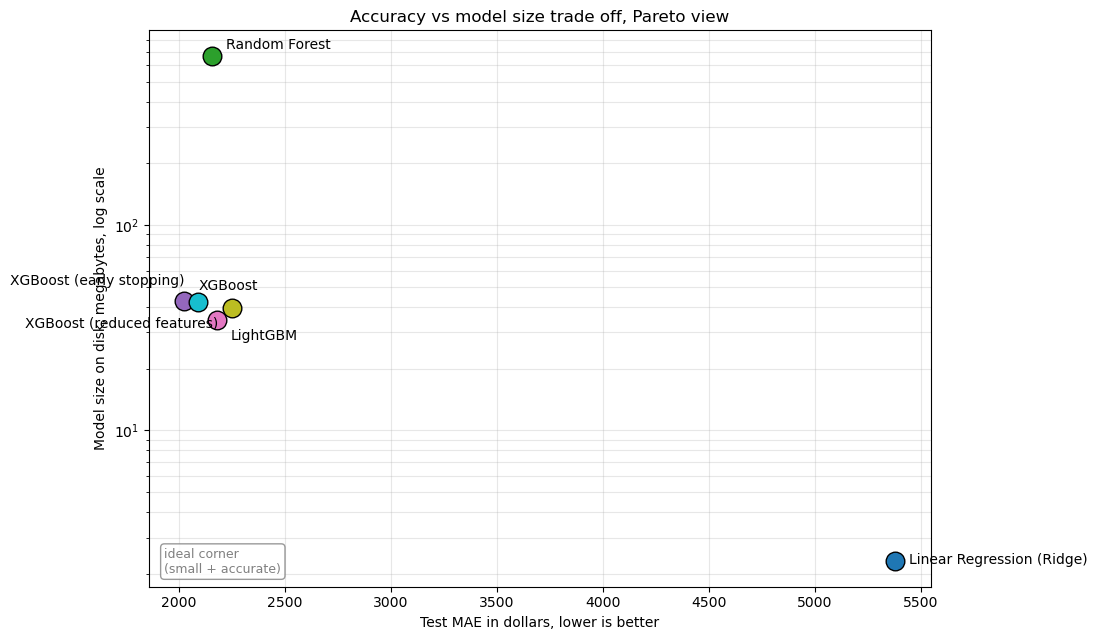

In [8]:
import os

print("Model file sizes on disk:")
filename_map = {
    "Linear Regression (Ridge)":   "linear_regression.pkl",
    "Random Forest":               "random_forest.pkl",
    "XGBoost":                     "xgboost.pkl",
    "LightGBM":                    "lightgbm.pkl",
    "KNN":                         "knn.pkl",
    "XGBoost (reduced features)":  "xgboost_reduced.pkl",
    "XGBoost (early stopping)":    "xgboost_early_stop.pkl",
}
for name in models:
    fname = filename_map.get(name)
    if fname is None:
        continue
    p = MODELS_DIR / fname
    if p.exists():
        size_mb = os.path.getsize(p) / (1024 * 1024)
        unit = "MB" if size_mb >= 1 else "KB"
        size_disp = size_mb if size_mb >= 1 else size_mb * 1024
        print(f"  {name:32}  {size_disp:>8.2f} {unit}")

# Pareto scatter. Test MAE on x. Model size on y in log scale.
# Bottom left corner is small and accurate.
import matplotlib.pyplot as plt

points = []
for name in models:
    fname = filename_map.get(name)
    if fname is None: continue
    p = MODELS_DIR / fname
    if p.exists() and name in metrics_df.index:
        size_mb = os.path.getsize(p) / (1024 * 1024)
        mae = metrics_df.loc[name, "MAE"]
        points.append((name, mae, size_mb))

if points:
    fig, ax = plt.subplots(figsize=(11, 6.5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(points)))
    # Label offsets to avoid overlap.
    label_offsets = {
        "Linear Regression (Ridge)":   (10, -2),
        "Random Forest":               (10, 5),
        "XGBoost":                     (10, 8),
        "LightGBM":                    (10, -14),
        "XGBoost (reduced features)":  (-10, -14),
        "XGBoost (early stopping)":    (-10, 12),
        "KNN":                         (10, 0),
    }
    for (name, mae, size_mb), color in zip(points, colors):
        ax.scatter(mae, size_mb, s=180, color=color, edgecolor="black", zorder=3)
        dx, dy = label_offsets.get(name, (8, 8))
        ha = "left" if dx >= 0 else "right"
        ax.annotate(name, (mae, size_mb),
                    xytext=(dx, dy), textcoords="offset points",
                    fontsize=10, ha=ha)
    ax.set_xlabel("Test MAE in dollars, lower is better")
    ax.set_ylabel("Model size on disk, megabytes, log scale")
    ax.set_yscale("log")
    ax.set_title("Accuracy vs model size trade off, Pareto view")
    ax.grid(True, which="both", alpha=0.3)
    ax.text(0.02, 0.02,
            "ideal corner\n(small + accurate)",
            transform=ax.transAxes, fontsize=9, color="gray",
            verticalalignment="bottom", horizontalalignment="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))
    plt.tight_layout()
    plt.show()


## 4.7 Conclusion and recommendation

This section pulls together what the cells above showed.

The metrics table in 4.2 has the per metric winner. The bar charts in 4.2 give the same numbers visually. Section 4.3 shows predictions vs actual price for each model. Section 4.4 compares feature importance across the tree models. Section 4.5 surfaces where the best model fails. Section 4.6 lists the trade offs in size and speed.

The recommendation cell below is auto generated from the metrics table. It picks the lowest test MAE model. Linear Ridge stays as the interpretability fallback because its coefficients give a clear dollar per feature explanation that trees cannot match.

Limitations
- Test set is from the same Craigslist scrape so it may not generalize to dealership listings.
- We did not use the free text description column. NLP was out of scope per the proposal.
- Geography is coarse. We use state but not region or zip code.
- The luxury car segment over 50000 dollars has high error.

Future work
- Try a neural network or a stacking ensemble.
- Add NLP features from the description column.
- Add finer geography.
- Calibrate the output with a Bayesian or quantile regression layer.


In [9]:
# Auto recommendation from the metrics table.
best_overall = metrics_df["MAE"].idxmin()
print(f"Recommended production model based on lowest test MAE: {best_overall}")
print(f"  MAE         = ${metrics_df.loc[best_overall, 'MAE']:,.2f}")
print(f"  RMSE        = ${metrics_df.loc[best_overall, 'RMSE']:,.2f}")
print(f"  R squared   = {metrics_df.loc[best_overall, 'R2']:.4f}")
print(f"  MAPE        = {metrics_df.loc[best_overall, 'MAPE']:.2f}%")
print()
print("Per metric winners")
for col, best in [("MAE", "min"), ("RMSE", "min"), ("R2", "max"), ("MAPE", "min")]:
    idx = metrics_df[col].idxmin() if best == "min" else metrics_df[col].idxmax()
    print(f"  {col:5}: {idx}")
print()
print("Linear Ridge stays as the interpretability fallback for explainability needs.")


Recommended production model based on lowest test MAE: XGBoost
  MAE         = $2,024.06
  RMSE        = $4,514.81
  R squared   = 0.9018
  MAPE        = 32.55%

Per metric winners
  MAE  : XGBoost
  RMSE : XGBoost
  R2   : XGBoost
  MAPE : XGBoost

Linear Ridge stays as the interpretability fallback for explainability needs.
